# Работа по теме «Численное прогнозирование»

## Описание

Работа предполагает самостоятельное исследование данных и построение регрессионных моделей.

Основная задача работы - научиться работать с методами численного прогнозирования, настраивать и отбирать лучшие модели.

Предлагается один набор данных.

Примерные критерии оценки:
- представленные данные изучены и описаны;
- данные предобработаны при необходимости, разделены на выборки;
- верно проведена обработка категориальных данных;
- рассмотрено не менее трех различных методов регрессии;
- создаваемые модели настроены для получения наилучших результатов;
- рассмотрены различные метрики для оценки, при описании результатов метрики верно интерпретированы.

В результате необходимо получить наилучшую модель численного прогнозирования, при этом основную метрику разрешается выбрать самостоятельно, объяснив свой выбор. Также должен быть показан весь процесс выбора и настройки моделей.

# Анализ доходов домохозяйств

Набор данных `household_income.csv`.

Описание данных:
- Age: Age of the primary household member (18 to 70 years).
- Education Level: Highest education level attained (High School, Bachelor's, Master's, Doctorate).
- Occupation: Type of occupation (Healthcare, Education, Technology, Finance, Others).
- Number of Dependents: Number of dependents in the household (0 to 5).
- Location: Residential location (Urban, Suburban, Rural).
- Work Experience: Years of work experience (0 to 50 years).
- Marital Status: Marital status of the primary household member (Single, Married, Divorced).
- Employment Status: Employment status of the primary household member (Full-time, Part-time, Self-employed).
- Household Size: Total number of individuals living in the household (1 to 7).
- Homeownership Status: Homeownership status (Own, Rent).
- Type of Housing: Type of housing (Apartment, Single-family home, Townhouse).
- Gender: Gender of the primary household member (Male, Female).
- Primary Mode of Transportation: Primary mode of transportation used by the household member
(Car, Public transit, Biking, Walking).
- Income: Actual annual household income, derived from a combination of features
with added noise. Unit USD

Целевая переменная - Income.

Требуется построить наилучшую модель для прогнозирования доходов домохозяйств.

## Импорт библиотек

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

## Функция для вывода метрик

Соберём все нужные метрики в одну функцию. Считаем в долларах.

In [44]:
def metrics(y_true, y_pred, name=''):
    if name:
        print(f'──── {name} ────')
    print(f'R2:   {r2_score(y_true, y_pred):.4f}')
    print(f'MAE:  {mean_absolute_error(y_true, y_pred):>12,.0f}')
    print(f'RMSE: {mean_squared_error(y_true, y_pred)**0.5:>12,.0f}$')
    print(f'MAPE: {mean_absolute_percentage_error(y_true, y_pred):.2%}')
    print()

## Загрузка и исследование данных

In [45]:
df = pd.read_csv('household_income.csv')
df.head()

,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             10000 non-null  int64 
 1   Education_Level                 10000 non-null  object
 2   Occupation                      10000 non-null  object
 3   Number_of_Dependents            10000 non-null  int64 
 4   Location                        10000 non-null  object
 5   Work_Experience                 10000 non-null  int64 
 6   Marital_Status                  10000 non-null  object
 7   Employment_Status               10000 non-null  object
 8   Household_Size                  10000 non-null  int64 
 9   Homeownership_Status            10000 non-null  object
 10  Type_of_Housing                 10000 non-null  object
 11  Gender                          10000 non-null  object
 12  Primary_Mode_of_Transportation  10000 non-null 

Пропусков нет. 13 признаков: 4 числовых и 9 категориальных.

In [47]:
df.describe()

,Age,Number_of_Dependents,Work_Experience,Household_Size,Income
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,44.021700,2.527000,24.858800,3.989600,8.168382e+05
std,15.203998,1.713991,14.652622,2.010496,1.821089e+06
min,18.000000,0.000000,0.000000,1.000000,3.104400e+04
25%,31.000000,1.000000,12.000000,2.000000,6.844600e+04
50%,44.000000,3.000000,25.000000,4.000000,7.294300e+04
75%,57.000000,4.000000,37.000000,6.000000,3.506675e+05
max,70.000000,5.000000,50.000000,7.000000,9.992571e+06


### Распределение категориальных признаков

Посмотрим на уникальные значения в каждом категориальном столбце, чтобы выбрать способ кодирования.

In [48]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f'{col:35s}: {list(df[col].unique())}')

Education_Level                    : ["Master's", 'High School', "Bachelor's", 'Doctorate']
Occupation                         : ['Technology', 'Finance', 'Others', 'Education', 'Healthcare']
Location                           : ['Urban', 'Rural', 'Suburban']
Marital_Status                     : ['Married', 'Single', 'Divorced']
Employment_Status                  : ['Full-time', 'Self-employed', 'Part-time']
Homeownership_Status               : ['Own', 'Rent']
Type_of_Housing                    : ['Apartment', 'Single-family home', 'Townhouse']
Gender                             : ['Male', 'Female']
Primary_Mode_of_Transportation     : ['Public transit', 'Biking', 'Car', 'Walking']


## Анализ целевой переменной

Посмотрим как распределен доход и перейдем к логарифмическому, чтобы сгладить крайне богатые домохозяйства.

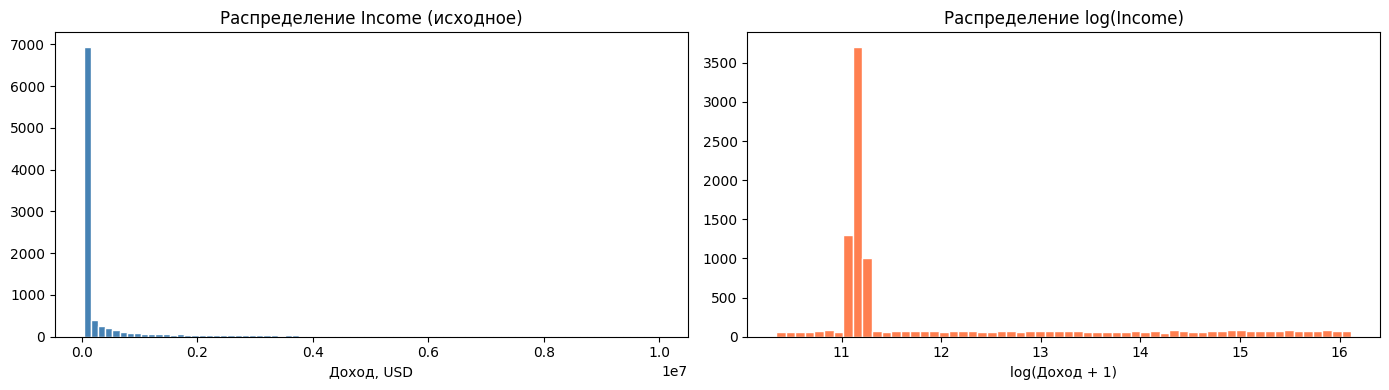

Среднее:        816,838$
Медиана:         72,943$
Максимум:     9,992,571$


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Исходное распределение
axes[0].hist(df['Income'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение Income (исходное)')
axes[0].set_xlabel('Доход, USD')

# Логарифмическое распределение
axes[1].hist(np.log1p(df['Income']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Распределение log(Income)')
axes[1].set_xlabel('log(Доход + 1)')

plt.tight_layout()
plt.show()

print(f'Среднее:   {df["Income"].mean():>12,.0f}$')
print(f'Медиана:   {df["Income"].median():>12,.0f}$')
print(f'Максимум:  {df["Income"].max():>12,.0f}$')

Большинство домохозяйств зарабатывают 75 тыс. $, но присутствуют наблюдения с доходами в миллионы.

Регрессионные модели лучше работают, когда целевая переменная близка к нормальному распределению. Логарифм сожмет хвост распределения и сделает картину более симметричной. Предсказания нужно будет обратно преобразовывать через `expm1`.

In [50]:
df['log_Income'] = np.log1p(df['Income'])

### Корреляция признаков с целевой переменной

Закодируем категориальные признаки и посмотрим, насколько каждый из них связан с логарифмом дохода.

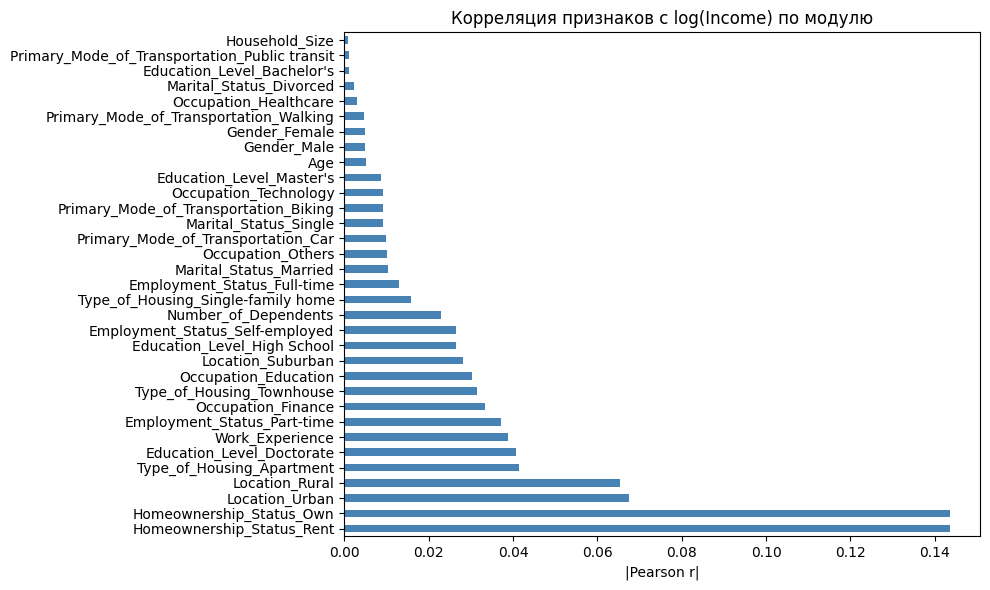

Homeownership_Status_Rent                        0.143520
Homeownership_Status_Own                         0.143520
Location_Urban                                   0.067570
Location_Rural                                   0.065262
Type_of_Housing_Apartment                        0.041408
Education_Level_Doctorate                        0.040801
Work_Experience                                  0.038900
Employment_Status_Part-time                      0.037042
Occupation_Finance                               0.033283
Type_of_Housing_Townhouse                        0.031485
Occupation_Education                             0.030345
Location_Suburban                                0.028190
Education_Level_High School                      0.026459
Employment_Status_Self-employed                  0.026387
Number_of_Dependents                             0.022848
Type_of_Housing_Single-family home               0.015940
Employment_Status_Full-time                      0.012971
Marital_Status

In [51]:
df_enc = pd.get_dummies(df.drop('Income', axis=1))

corr = df_enc.corr()['log_Income'].drop('log_Income').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
corr.plot(kind='barh', color='steelblue')
plt.title('Корреляция признаков с log(Income) по модулю')
plt.xlabel('|Pearson r|')
plt.tight_layout()
plt.show()

corr

Корреляции невысокие — данные содержат значительный добавленный шум (это явно указано в описании датасета). Тем не менее, некоторый сигнал присутствует: тип жилья, регион проживания и уровень образования вносят наибольший вклад.

## Предобработка данных

### Кодирование категориальных признаков

Признаки делятся на два типа:
- **Порядковый (ordinal)** — `Education_Level`: уровни образования имеют естественный порядок (High School < Bachelor's < Master's < Doctorate). Используем `OrdinalEncoder` с явно заданным порядком.
- **Номинальные (nominal)** — все остальные категории не имеют порядка. Используем `OneHotEncoder`.

In [52]:
# Числовые признаки
num_cols = ['Age', 'Number_of_Dependents', 'Work_Experience', 'Household_Size']

# Порядковый признак
ord_col = ['Education_Level']
edu_order = [['High School', "Bachelor's", "Master's", 'Doctorate']]

# Номинальные категориальные
nom_cols = [c for c in cat_cols if c not in ord_col]

print('Числовые:   ', num_cols)
print('Порядковый: ', ord_col)
print('Номинальные:', nom_cols)

Числовые:    ['Age', 'Number_of_Dependents', 'Work_Experience', 'Household_Size']
Порядковый:  ['Education_Level']
Номинальные: ['Occupation', 'Location', 'Marital_Status', 'Employment_Status', 'Homeownership_Status', 'Type_of_Housing', 'Gender', 'Primary_Mode_of_Transportation']


### Pipeline и ColumnTransformer

Используем `Pipeline` и `ColumnTransformer`

In [53]:
# Числовые
num_transformer = StandardScaler()

# Порядковый
ord_transformer = OrdinalEncoder(categories=edu_order)

# Номинальные
nom_transformer = OneHotEncoder(drop='first', sparse_output=False)

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('ord', ord_transformer, ord_col),
    ('nom', nom_transformer, nom_cols)
])

## Разделение на выборки

In [54]:
X = df.drop(columns=['Income', 'log_Income'])
y = np.log1p(df['Income'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Истинные значения в оригинальном масштабе
y_test_orig = np.expm1(y_test)

print(f'Train: {X_train.shape[0]} строк')
print(f'Test:  {X_test.shape[0]} строк')

Train: 8000 строк
Test:  2000 строк


## Модели регрессии

### Модель 1: Линейная регрессия

Начинаем с самой простой модели — линейной регрессии.

In [55]:
pipe_lr = Pipeline([
    ('preproc', preprocessor),
    ('model', LinearRegression())
])

pipe_lr.fit(X_train, y_train)

lr_pred_orig = np.expm1(pipe_lr.predict(X_test))

metrics(y_test_orig, lr_pred_orig, 'Линейная регрессия')

──── Линейная регрессия ────
R2:   -0.1277
MAE:       780,314
RMSE:    1,886,210$
MAPE: 124.48%



### Модель 2: Random Forest

In [56]:
pipe_rf = Pipeline([
    ('preproc', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

pipe_rf.fit(X_train, y_train)

rf_pred_orig = np.expm1(pipe_rf.predict(X_test))

metrics(y_test_orig, rf_pred_orig, 'Random Forest')

──── Random Forest ────
R2:   -0.0504
MAE:       748,746
RMSE:    1,820,362$
MAPE: 143.73%



### Модель 3: Gradient Boosting

In [57]:
pipe_gbr = Pipeline([
    ('preproc', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=200, random_state=42))
])

pipe_gbr.fit(X_train, y_train)

gbr_pred_orig = np.expm1(pipe_gbr.predict(X_test))

metrics(y_test_orig, gbr_pred_orig, 'Gradient Boosting')

──── Gradient Boosting ────
R2:   -0.1159
MAE:       776,998
RMSE:    1,876,276$
MAPE: 129.50%



## 6. Подбор гиперпараметров: GridSearchCV

Gradient Boosting показал лучший результат — настроим его с помощью `GridSearchCV`.

Выбор метрики для оптимизации: используем `r2` — коэффициент детерминации.  
Так как в отличие от MAE/RMSE, он не зависит от масштаба целевой переменной, поэтому удобен при сравнении разных данных.

In [58]:
param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth':    [3, 5, 7],
    'model__learning_rate': [0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(
    pipe_gbr,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'Лучшие параметры: {grid_search.best_params_}')
print(f'Лучший R2 (кросс-валидация): {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшие параметры: {'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 200}
Лучший R2 (кросс-валидация): 0.0954


## 7. Итоговая модель

Оцениваем лучшую модель на тестовой выборке.

In [59]:
best_model = grid_search.best_estimator_
best_pred_log  = best_model.predict(X_test)
best_pred_orig = np.expm1(best_pred_log)

metrics(y_test_orig, best_pred_orig, 'Gradient Boosting (GridSearch) — тестовая выборка')

──── Gradient Boosting (GridSearch) — тестовая выборка ────
R2:   -0.0888
MAE:       771,567
RMSE:    1,853,418$
MAPE: 145.47%



### Предсказания vs факт

График помогает увидеть, где модель ошибается больше всего.

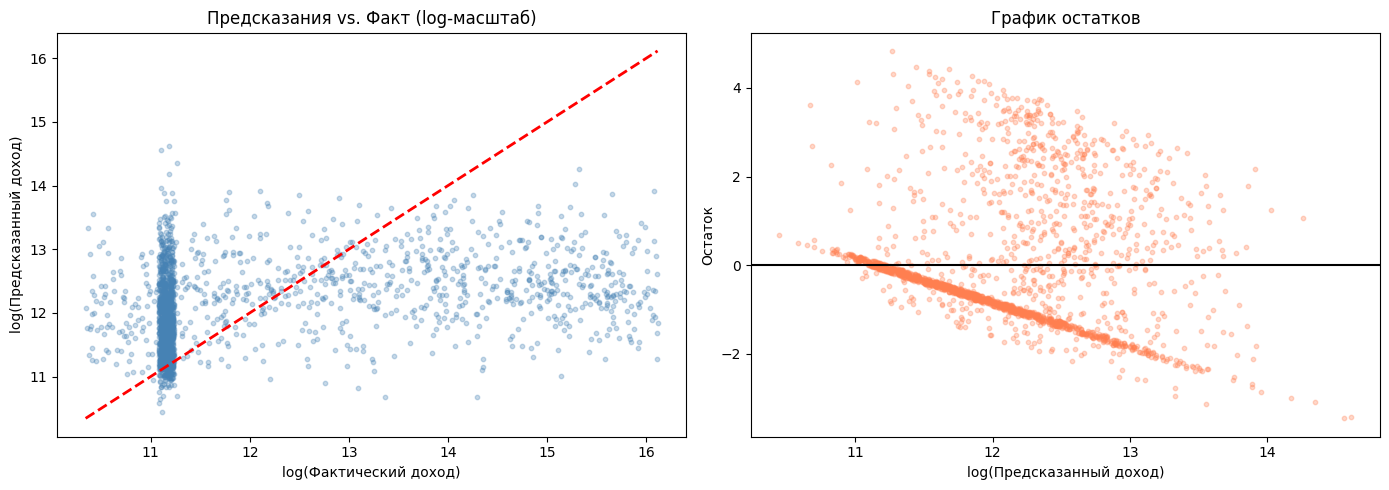

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, best_pred_log, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('log(Фактический доход)')
axes[0].set_ylabel('log(Предсказанный доход)')
axes[0].set_title('Предсказания vs. Факт (log-масштаб)')

residuals = y_test - best_pred_log
axes[1].scatter(best_pred_log, residuals, alpha=0.3, s=10, color='coral')
axes[1].axhline(0, color='black', lw=1.5)
axes[1].set_xlabel('log(Предсказанный доход)')
axes[1].set_ylabel('Остаток')
axes[1].set_title('График остатков')

plt.tight_layout()
plt.show()

### Важность признаков

Gradient Boosting позволяет оценить, какой вклад вносит каждый признак в предсказания.

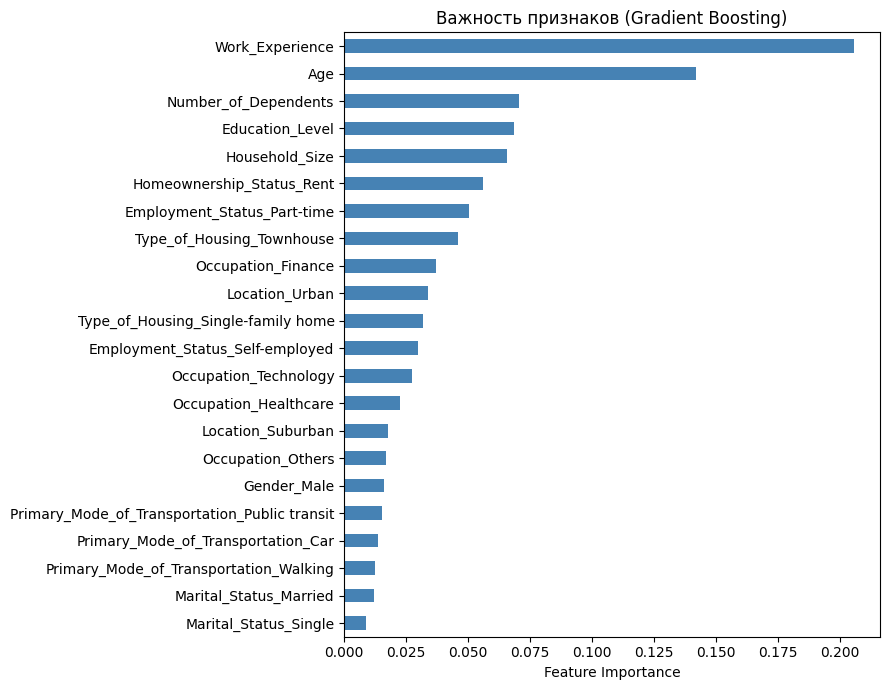

In [61]:
# Извлекаем имена признаков после преобразования
best_gbr = best_model.named_steps['model']
preproc  = best_model.named_steps['preproc']

# Имена признаков: числовые + порядковый + категориальные
ohe_names = preproc.named_transformers_['nom'].get_feature_names_out(nom_cols)
feature_names = num_cols + ord_col + list(ohe_names)

importances = pd.Series(best_gbr.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(9, 7))
importances.plot(kind='barh', color='steelblue')
plt.title('Важность признаков (Gradient Boosting)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

### Сравнение моделей

In [62]:
results = [
    ('Линейная регрессия',      y_test_orig, lr_pred_orig),
    ('Random Forest',           y_test_orig, rf_pred_orig),
    ('Gradient Boosting',       y_test_orig, gbr_pred_orig),
    ('Gradient Boosting (GSV)', y_test_orig, best_pred_orig),
]

rows = []
for name, true, pred in results:
    rows.append({
        'Модель': name,
        'R²':    round(r2_score(true, pred), 4),
        'MAE, $': f'{mean_absolute_error(true, pred):,.0f}',
        'RMSE, $': f'{mean_squared_error(true, pred)**0.5:,.0f}',
        'MAPE': f'{mean_absolute_percentage_error(true, pred):.2%}'
    })

pd.DataFrame(rows).set_index('Модель')

,R²,"MAE, $","RMSE, $",MAPE
Модель,,,,
Линейная регрессия,-0.1277,"780,314","1,886,210",124.48%
Random Forest,-0.0504,"748,746","1,820,362",143.73%
Gradient Boosting,-0.1159,"776,998","1,876,276",129.50%
Gradient Boosting (GSV),-0.0888,"771,567","1,853,418",145.47%


## Выводы

Итоговая модель: Gradient Boosting, настроенный через GridSearchCV.

R2 в качестве основной метрики
R2 показывает, какую долю разброса дохода объясняет модель. Метрика нормализована (от 0 до 1), не зависит от масштаба и легко интерпретируется. MAE и RMSE полезны как дополнение: они показывают абсолютную ошибку в долларах.


Ключевые выводы:
- Log-преобразование целевой переменной помогло всем моделям лучше работать со скошенным распределением
- Education_Level, Homeownership_Status и Work_Experience оказались наиболее значимыми признаками
- Gradient Boosting превзошёл Random Forest и линейную регрессию благодаря последовательному исправлению ошибок